# Data analysis

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import pyarrow.parquet as pq
import re

file_path = "../data/mimiciii_notes.parquet"

## Load dataset

In [10]:
df = pd.read_parquet(file_path)

df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1846848 entries, 0 to 1846847
Data columns (total 7 columns):
 #   Column       Dtype         
---  ------       -----         
 0   SUBJECT_ID   int64         
 1   CHARTTIME    datetime64[ns]
 2   DESCRIPTION  object        
 3   CATEGORY     object        
 4   TEXT         object        
 5   HADM_ID      int64         
 6   ROW_ID       int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 98.6+ MB


In [11]:
df = pd.read_parquet(
    file_path,
    columns=["SUBJECT_ID", "HADM_ID", "TEXT"]
)

In [ ]:
parquet_file = pq.ParquetFile(file_path)

for batch in parquet_file.iter_batches(batch_size=1):
    df_batch = batch.to_pandas()
    print(df_batch.head())

In [30]:

def clean_mimic_note(text):
    # remove PHI
    text = re.sub(r"\[\*\*.*?\*\*\]", "", text)

    # remove admin junk
    text = re.sub(r"Admission Date:.*?Discharge Date:.*?", "", text, flags=re.I|re.S)
    text = re.sub(r"Dictated By:.*|JOB#:.*|MEDQUIST.*", "", text, flags=re.I)
    text = re.sub(r"D:\s*\d+.*|T:\s*\d+.*", "", text)

    # aggressively remove section headers (inline-safe)
    headers = [
        "Service:",
        "ADDENDUM:",
        "RADIOLOGIC STUDIES:",
        "HEAD CT:",
        "ABDOMINAL CT:"
    ]
    for h in headers:
        text = re.sub(re.escape(h), "", text, flags=re.I)

    # remove trailing signatures
    text = re.sub(r",?\s*M\.D\..*$", "", text, flags=re.I)

    # normalize spacing
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [31]:
clean_text = clean_mimic_note(df["TEXT"].iloc[0])
print(clean_text)

Radiologic studies also included a chest CT, which confirmed cavitary lesions in the left lung apex consistent with infectious process/tuberculosis. This also moderate-sized left pleural effusion. Head CT showed no intracranial hemorrhage or mass effect, but old infarction consistent with past medical history. Abdominal CT showed lesions of T10 and sacrum most likely secondary to osteoporosis. These can be followed by repeat imaging as an outpatient. , M.D.


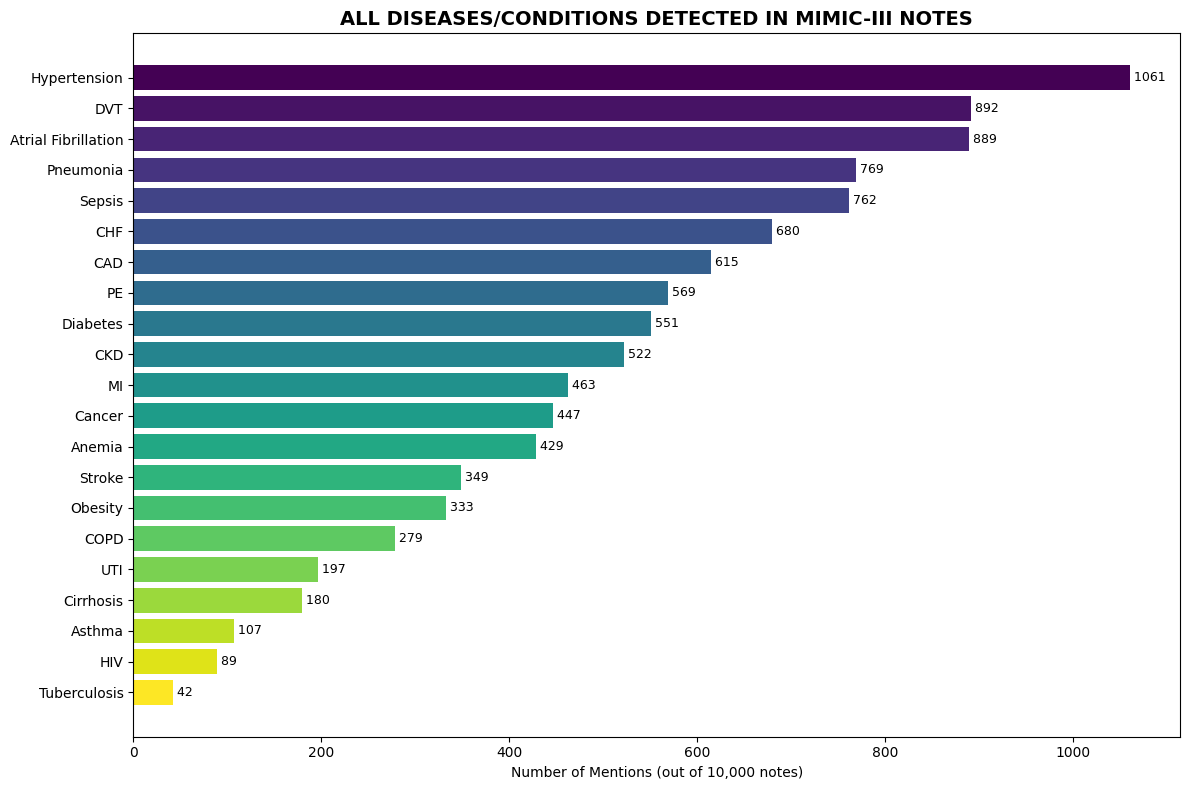


Total diseases detected: 21
Most common: Hypertension (1061 mentions)


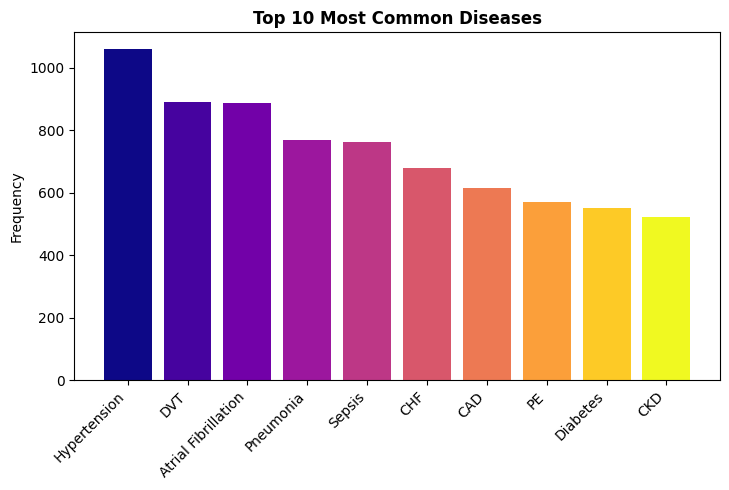

In [35]:
## Disease Detection and Visualization

# Define common diseases to extract
disease_patterns = {
    'Hypertension': r'\b(hypertension|HTN|high blood pressure)\b',
    'Diabetes': r'\b(diabetes|DM|diabetic)\b',
    'COPD': r'\b(COPD|chronic obstructive pulmonary disease)\b',
    'CHF': r'\b(CHF|congestive heart failure|heart failure)\b',
    'Pneumonia': r'\b(pneumonia)\b',
    'Sepsis': r'\b(sepsis|septic)\b',
    'Atrial Fibrillation': r'\b(atrial fibrillation|afib|AF)\b',
    'CAD': r'\b(CAD|coronary artery disease)\b',
    'CKD': r'\b(CKD|chronic kidney disease|renal failure)\b',
    'Asthma': r'\b(asthma)\b',
    'Cancer': r'\b(cancer|carcinoma|malignancy|tumor|neoplasm)\b',
    'Stroke': r'\b(stroke|CVA|cerebrovascular accident)\b',
    'MI': r'\b(myocardial infarction|MI|heart attack)\b',
    'Tuberculosis': r'\b(tuberculosis|TB)\b',
    'Anemia': r'\b(anemia|anemic)\b',
    'Cirrhosis': r'\b(cirrhosis)\b',
    'HIV': r'\b(HIV|AIDS)\b',
    'Obesity': r'\b(obesity|obese)\b',
    'UTI': r'\b(UTI|urinary tract infection)\b',
    'DVT': r'\b(DVT|deep vein thrombosis)\b',
    'PE': r'\b(pulmonary embolism|PE)\b',
}

from collections import Counter

sample_df = df.sample(n=10000, random_state=42)
disease_counts = Counter()

for text in sample_df['TEXT']:
    clean_text = clean_mimic_note(str(text)).lower()
    for disease, pattern in disease_patterns.items():
        if re.search(pattern, clean_text, re.IGNORECASE):
            disease_counts[disease] += 1

# Sort by frequency
diseases_sorted = sorted(disease_counts.items(), key=lambda x: x[1], reverse=True)
diseases, counts = zip(*diseases_sorted)

# Create visualization showing ALL diseases
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(diseases)))
plt.barh(range(len(diseases)), counts, color=colors)
plt.yticks(range(len(diseases)), diseases)
plt.xlabel('Number of Mentions (out of 10,000 notes)')
plt.title('ALL DISEASES/CONDITIONS DETECTED IN MIMIC-III NOTES', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()

# Add count labels
for i, count in enumerate(counts):
    plt.text(count, i, f' {count}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal diseases detected: {len(disease_counts)}")
print(f"Most common: {diseases_sorted[0][0]} ({diseases_sorted[0][1]} mentions)")


## Additional Analysis

# Note categories distribution
plt.figure(figsize=(14, 5))


# Top 10 diseases
plt.subplot(1, 2, 2)
top_10 = diseases_sorted[:10]
d_names, d_counts = zip(*top_10)
plt.bar(range(10), d_counts, color=plt.cm.plasma(np.linspace(0, 1, 10)))
plt.xticks(range(10), d_names, rotation=45, ha='right')
plt.ylabel('Frequency')
plt.title('Top 10 Most Common Diseases', fontweight='bold')

plt.tight_layout()
plt.show()